# DSAI 490 — Assignment 1: AE & VAE per Anatomical Region
**Medical MNIST | One AE + One VAE trained per region | T4 GPU**

## 1. Mount Drive & Copy to Local Disk

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os
LOCAL_DIR = '/content/drive/MyDrive/medical_mnist/archive '
REGIONS = sorted([
    e.name for e in os.scandir(LOCAL_DIR) if e.is_dir()
])
print('Regions found:', REGIONS)
print('Number of regions:', len(REGIONS))

Mounted at /content/drive
Regions found: ['AbdomenCT', 'BreastMRI', 'CXR', 'ChestCT', 'Hand', 'HeadCT']
Number of regions: 6


## 2. Imports & Config

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

tf.random.set_seed(42)
np.random.seed(42)

IMG_SIZE   = 64
BATCH_SIZE = 256
LATENT_DIM = 16
EPOCHS     = 15
AUTOTUNE   = tf.data.AUTOTUNE

print('TF:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TF: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 3. Data Utilities

In [3]:
def load_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=1)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def get_paths(region):
    """Return all image paths for a given region."""
    paths = []
    for ext in ('*.jpeg', '*.jpg', '*.png'):
        paths += [str(p) for p in Path(LOCAL_DIR, region).glob(ext)]
    return paths

def make_region_ds(paths, training=True):
    """tf.data dataset returning (img, img) for reconstruction."""
    labels = [0] * len(paths)  # dummy label (single region)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.map(lambda img, _: (img, img))
    if training:
        ds = ds.shuffle(4096)
    ds = ds.cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

def make_vis_ds(paths):
    """Dataset returning raw images (no target) for latent viz."""
    labels = [0] * len(paths)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

# Pre-split paths per region
region_splits = {}
for region in REGIONS:
    all_p = get_paths(region)
    np.random.shuffle(all_p)
    cut = int(0.9 * len(all_p))
    region_splits[region] = {'train': all_p[:cut], 'val': all_p[cut:]}
    print(f'{region:15s} → train: {cut:4d} | val: {len(all_p)-cut:4d}')

AbdomenCT       → train: 9000 | val: 1000
BreastMRI       → train: 8058 | val:  896
CXR             → train: 9000 | val: 1000
ChestCT         → train: 9000 | val: 1000
Hand            → train: 9000 | val: 1000
HeadCT          → train: 9000 | val: 1000


## 4. Model Factory

In [4]:
# ─── Encoder ──────────────────────────────────────────────────────
def build_encoder(variational=False, name_prefix=''):
    inp = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 1))
    x = tf.keras.layers.Conv2D(32,  3, strides=2, activation='relu', padding='same')(inp)
    x = tf.keras.layers.Conv2D(64,  3, strides=2, activation='relu', padding='same')(x)
    x = tf.keras.layers.Conv2D(128, 3, strides=2, activation='relu', padding='same')(x)
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    if variational:
        mu = tf.keras.layers.Dense(LATENT_DIM, name='z_mean')(x)
        lv = tf.keras.layers.Dense(LATENT_DIM, name='z_log_var')(x)
        return tf.keras.Model(inp, [mu, lv], name=f'{name_prefix}_vae_enc')
    z = tf.keras.layers.Dense(LATENT_DIM, name='z')(x)
    return tf.keras.Model(inp, z, name=f'{name_prefix}_ae_enc')

# ─── Decoder ──────────────────────────────────────────────────────
def build_decoder(name_prefix=''):
    s = IMG_SIZE // 8
    inp = tf.keras.Input(shape=(LATENT_DIM,))
    x = tf.keras.layers.Dense(s*s*128, activation='relu')(inp)
    x = tf.keras.layers.Reshape((s, s, 128))(x)
    x = tf.keras.layers.Conv2DTranspose(128, 3, strides=2, activation='relu', padding='same')(x)
    x = tf.keras.layers.Conv2DTranspose(64,  3, strides=2, activation='relu', padding='same')(x)
    x = tf.keras.layers.Conv2DTranspose(32,  3, strides=2, activation='relu', padding='same')(x)
    out = tf.keras.layers.Conv2D(1, 3, activation='sigmoid', padding='same')(x)
    return tf.keras.Model(inp, out, name=f'{name_prefix}_dec')

# ─── AE factory ───────────────────────────────────────────────────
def build_ae(region):
    enc = build_encoder(variational=False, name_prefix=region)
    dec = build_decoder(name_prefix=region)
    inp = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 1))
    model = tf.keras.Model(inp, dec(enc(inp)), name=f'AE_{region}')
    model.compile(optimizer='adam', loss='mse')
    return model, enc, dec

# ─── VAE class ────────────────────────────────────────────────────
class Sampling(tf.keras.layers.Layer):
    def call(self, inputs):
        mu, lv = inputs
        return mu + tf.exp(0.5 * lv) * tf.random.normal(tf.shape(mu))

class VAE(tf.keras.Model):
    def __init__(self, enc, dec, **kw):
        super().__init__(**kw)
        self.enc    = enc
        self.dec    = dec
        self.sample = Sampling()
        self.t_loss = tf.keras.metrics.Mean('total_loss')
        self.r_loss = tf.keras.metrics.Mean('recon_loss')
        self.k_loss = tf.keras.metrics.Mean('kl_loss')

    @property
    def metrics(self): return [self.t_loss, self.r_loss, self.k_loss]

    def call(self, x):
        mu, lv = self.enc(x)
        return self.dec(self.sample([mu, lv]))

    def _compute(self, x, training):
        mu, lv = self.enc(x, training=training)
        xhat   = self.dec(self.sample([mu, lv]), training=training)
        r  = tf.reduce_mean(tf.reduce_sum(tf.square(x - xhat), axis=[1,2,3]))
        kl = -0.5 * tf.reduce_mean(1 + lv - tf.square(mu) - tf.exp(lv))
        return r + kl, r, kl

    def train_step(self, data):
        x, _ = data
        with tf.GradientTape() as tape:
            loss, r, kl = self._compute(x, True)
        self.optimizer.apply_gradients(
            zip(tape.gradient(loss, self.trainable_variables), self.trainable_variables))
        self.t_loss.update_state(loss); self.r_loss.update_state(r); self.k_loss.update_state(kl)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        x, _ = data
        loss, r, kl = self._compute(x, False)
        self.t_loss.update_state(loss); self.r_loss.update_state(r); self.k_loss.update_state(kl)
        return {m.name: m.result() for m in self.metrics}

def build_vae(region):
    enc = build_encoder(variational=True, name_prefix=region)
    dec = build_decoder(name_prefix=region)
    model = VAE(enc, dec, name=f'VAE_{region}')
    model.compile(optimizer='adam')
    return model, enc, dec

print('Model factory ready ✓')

Model factory ready ✓


## 5. Train AE + VAE for Every Region
> Trains one AE and one VAE per anatomical region. Results stored in `results` dict.

In [5]:
print(f"  Train paths sample: {region_splits[region]['train'][:2]}")

  Train paths sample: ['/content/drive/MyDrive/medical_mnist/archive /HeadCT/008302.jpeg', '/content/drive/MyDrive/medical_mnist/archive /HeadCT/009441.jpeg']


In [6]:
results = {}   # region → {ae, vae, ae_enc, vae_enc, vae_dec, ae_hist, vae_hist}

callbacks = [tf.keras.callbacks.EarlyStopping(
    patience=3, restore_best_weights=True, verbose=0)]

for region in REGIONS:
    print(f'\n{'='*55}')
    print(f'  Region: {region}')
    print(f'{'='*55}')

    tr_ds = make_region_ds(region_splits[region]['train'], training=True)
    va_ds = make_region_ds(region_splits[region]['val'],   training=False)

    # ── AE ──
    print(f'  [AE]')
    ae, ae_enc, ae_dec = build_ae(region)
    ae_hist = ae.fit(tr_ds, validation_data=va_ds,
                     epochs=EPOCHS, callbacks=callbacks, verbose=1)

    # ── VAE ──
    print(f'  [VAE]')
    vae, vae_enc, vae_dec = build_vae(region)
    vae_hist = vae.fit(tr_ds, validation_data=va_ds,
                       epochs=EPOCHS, callbacks=callbacks, verbose=1)

    results[region] = dict(
        ae=ae, vae=vae,
        ae_enc=ae_enc, vae_enc=vae_enc, vae_dec=vae_dec,
        ae_hist=ae_hist, vae_hist=vae_hist,
        val_paths=region_splits[region]['val']
    )

print('\n✓ All regions trained.')


  Region: AbdomenCT
  [AE]
Epoch 1/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 189s 646ms/step - loss: 0.0109 - val_loss: 0.0082
Epoch 2/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.0079 - val_loss: 0.0079
Epoch 3/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.0073 - val_loss: 0.0064
Epoch 4/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.0059 - val_loss: 0.0055
Epoch 5/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.0052 - val_loss: 0.0050
Epoch 6/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.0047 - val_loss: 0.0046
Epoch 7/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.0043 - val_loss: 0.0043
Epoch 8/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.0041 - val_loss: 0.0040
Epoch 9/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.0038 - val_loss: 0.0037
Epoch 10/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.0036 - val_loss: 0.0036
Epoch 11/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.0034 - val_loss: 0.0035
Epoch 12/15
36/36 ━━━━━━━━━━━━━━

## 6. Loss Curves — All Regions

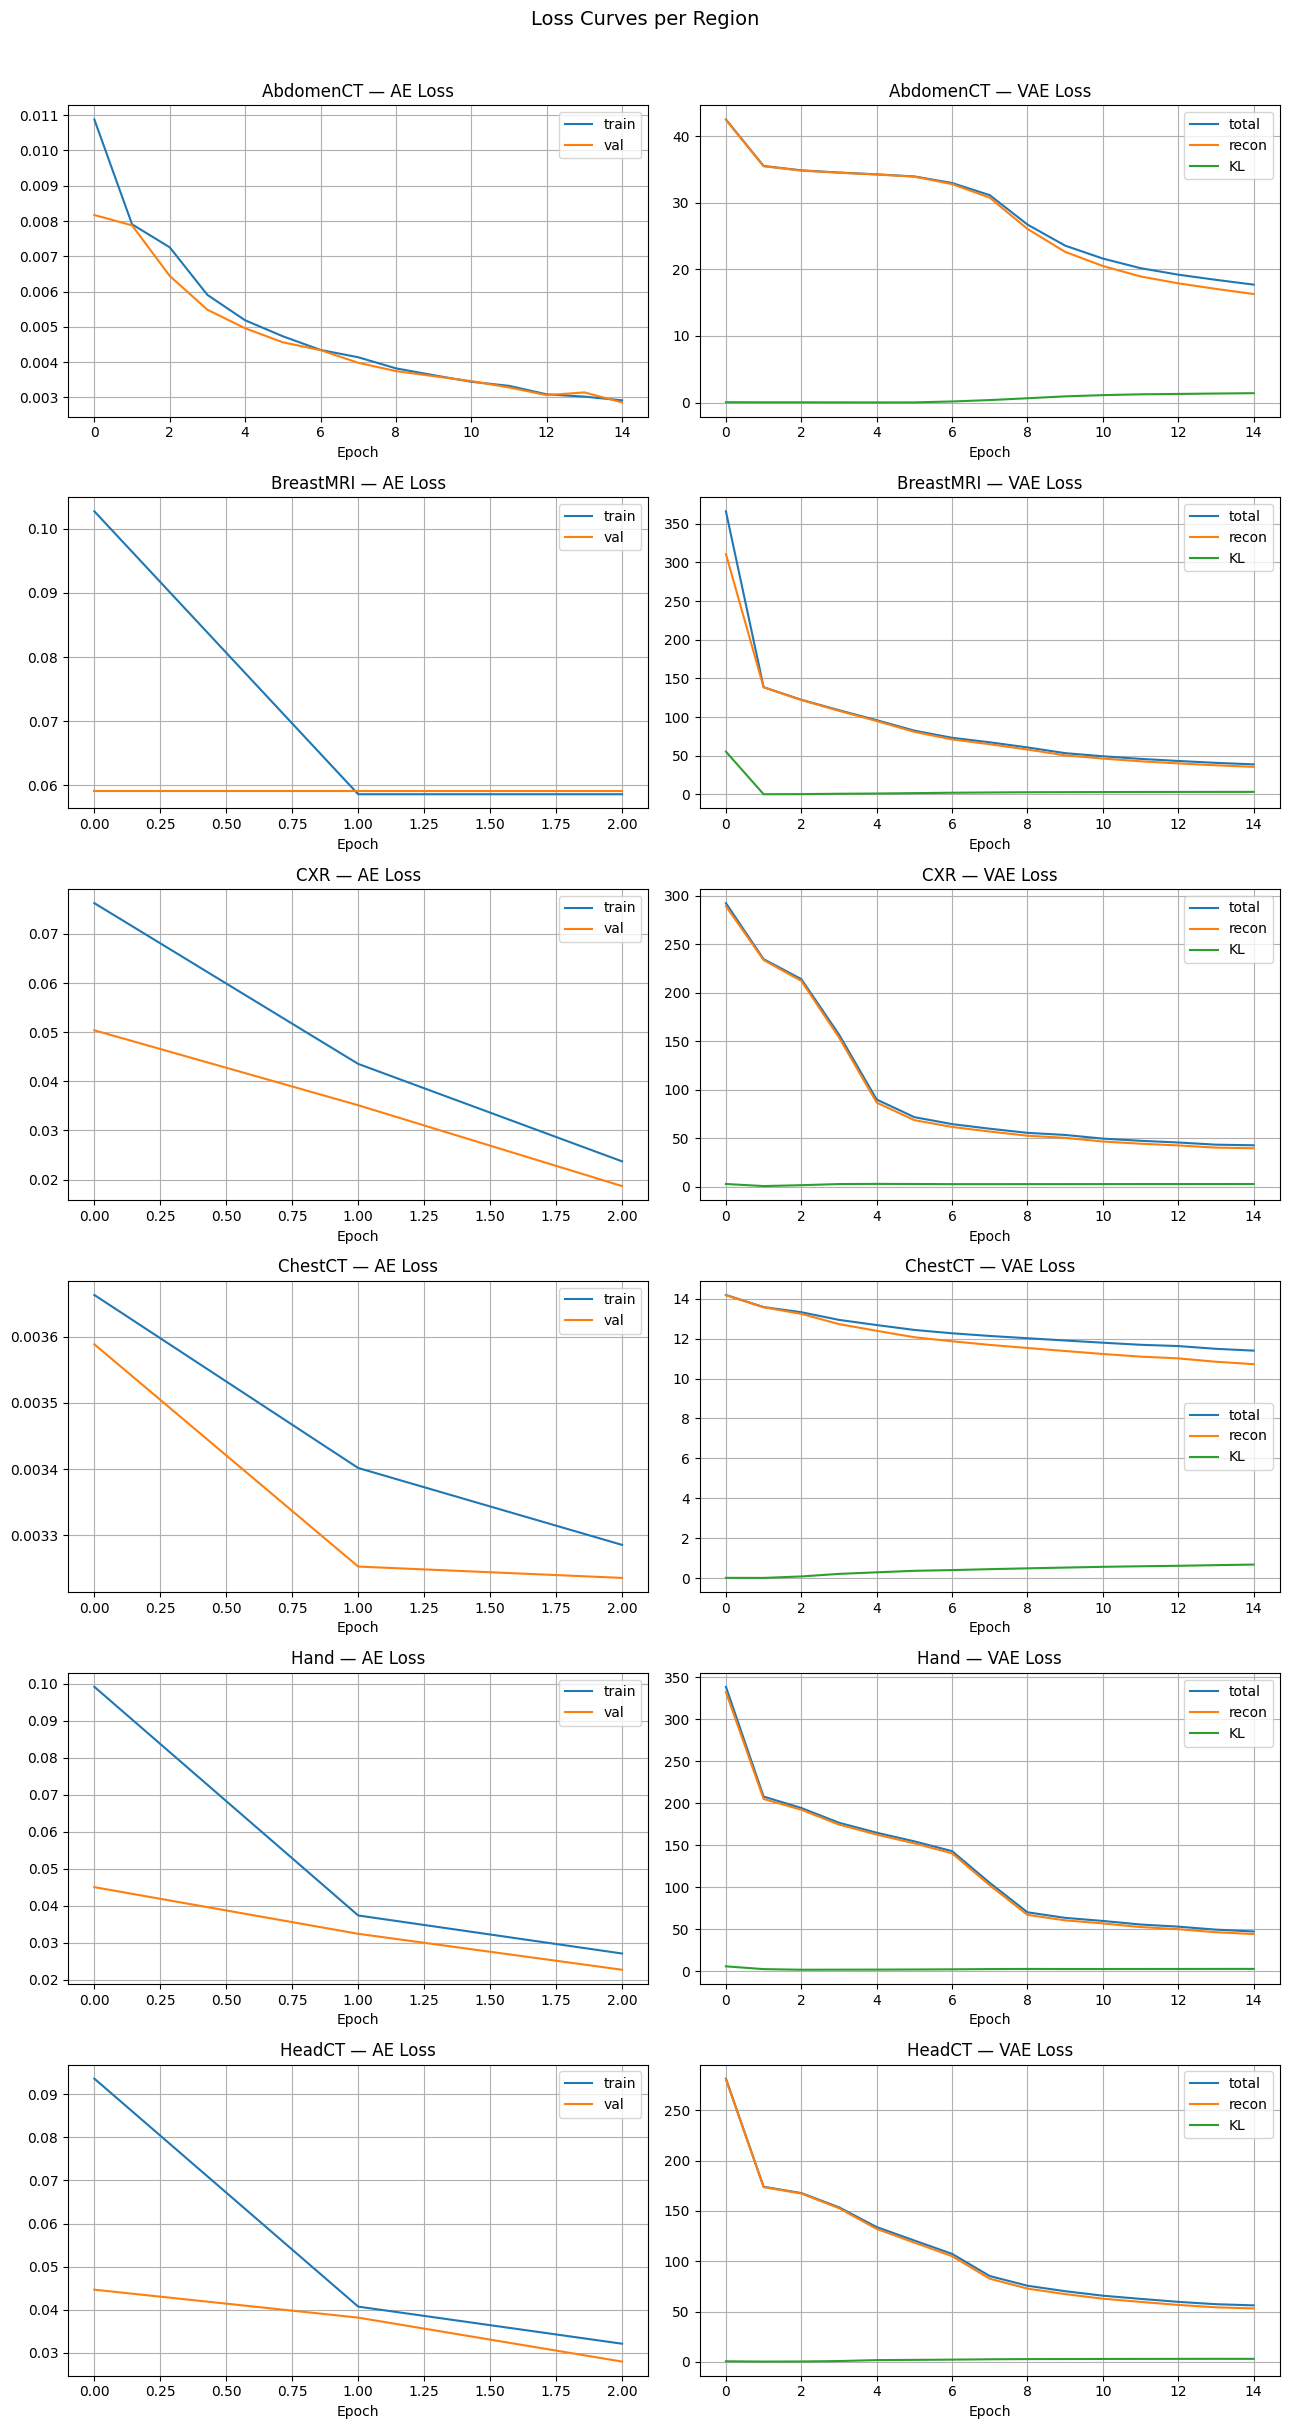

In [7]:
n = len(REGIONS)
fig, axes = plt.subplots(n, 2, figsize=(13, 4*n))

for i, region in enumerate(REGIONS):
    r = results[region]
    ah, vh = r['ae_hist'].history, r['vae_hist'].history

    # AE
    axes[i,0].plot(ah['loss'],     label='train')
    axes[i,0].plot(ah['val_loss'], label='val')
    axes[i,0].set_title(f'{region} — AE Loss')
    axes[i,0].set_xlabel('Epoch'); axes[i,0].legend(); axes[i,0].grid(True)

    # VAE
    axes[i,1].plot(vh['total_loss'], label='total')
    axes[i,1].plot(vh['recon_loss'], label='recon')
    axes[i,1].plot(vh['kl_loss'],    label='KL')
    axes[i,1].set_title(f'{region} — VAE Loss')
    axes[i,1].set_xlabel('Epoch'); axes[i,1].legend(); axes[i,1].grid(True)

plt.suptitle('Loss Curves per Region', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('loss_curves_all_regions.png', dpi=100, bbox_inches='tight')
plt.show()

## 7. Reconstruction — All Regions

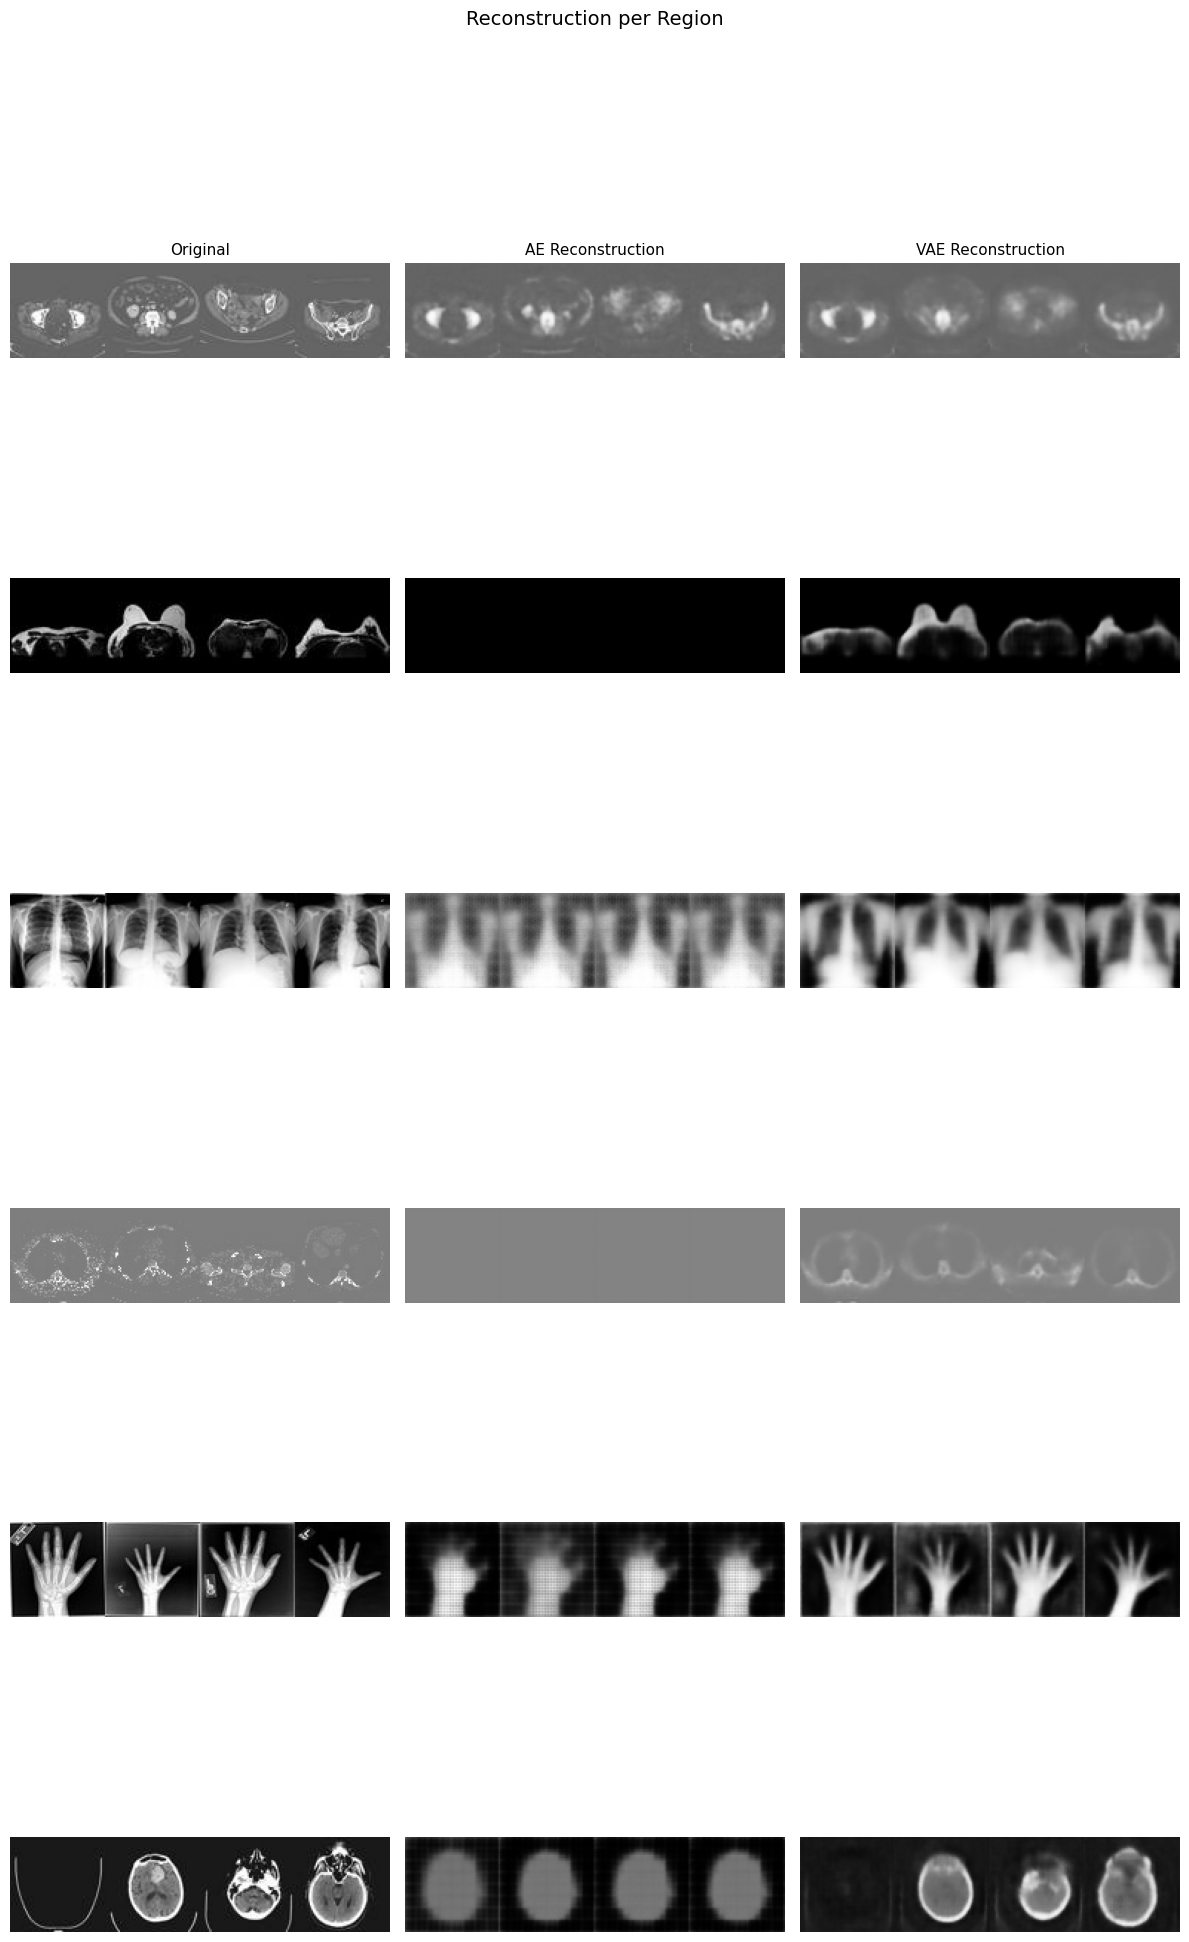

In [8]:
fig, axes = plt.subplots(n, 3, figsize=(12, 3.5*n))
if n == 1: axes = axes[np.newaxis, :]

for i, region in enumerate(REGIONS):
    r  = results[region]
    va_ds = make_region_ds(r['val_paths'], training=False)
    orig  = next(iter(va_ds))[0][:8].numpy()

    ae_recon  = r['ae'].predict(orig,  verbose=0)
    vae_recon = r['vae'].predict(orig, verbose=0)

    # Show 4 samples per model in a strip
    def make_strip(imgs, n_show=4):
        strip = np.concatenate([imgs[j].squeeze() for j in range(n_show)], axis=1)
        return strip

    axes[i,0].imshow(make_strip(orig),      cmap='gray', vmin=0, vmax=1)
    axes[i,1].imshow(make_strip(ae_recon),  cmap='gray', vmin=0, vmax=1)
    axes[i,2].imshow(make_strip(vae_recon), cmap='gray', vmin=0, vmax=1)

    axes[i,0].set_ylabel(region, fontsize=10)
    for ax in axes[i]: ax.axis('off')

for ax, title in zip(axes[0], ['Original', 'AE Reconstruction', 'VAE Reconstruction']):
    ax.set_title(title, fontsize=11)

plt.suptitle('Reconstruction per Region', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('reconstruction_all_regions.png', dpi=100, bbox_inches='tight')
plt.show()

## 8. Latent Space Visualization — All Regions (PCA + t-SNE)

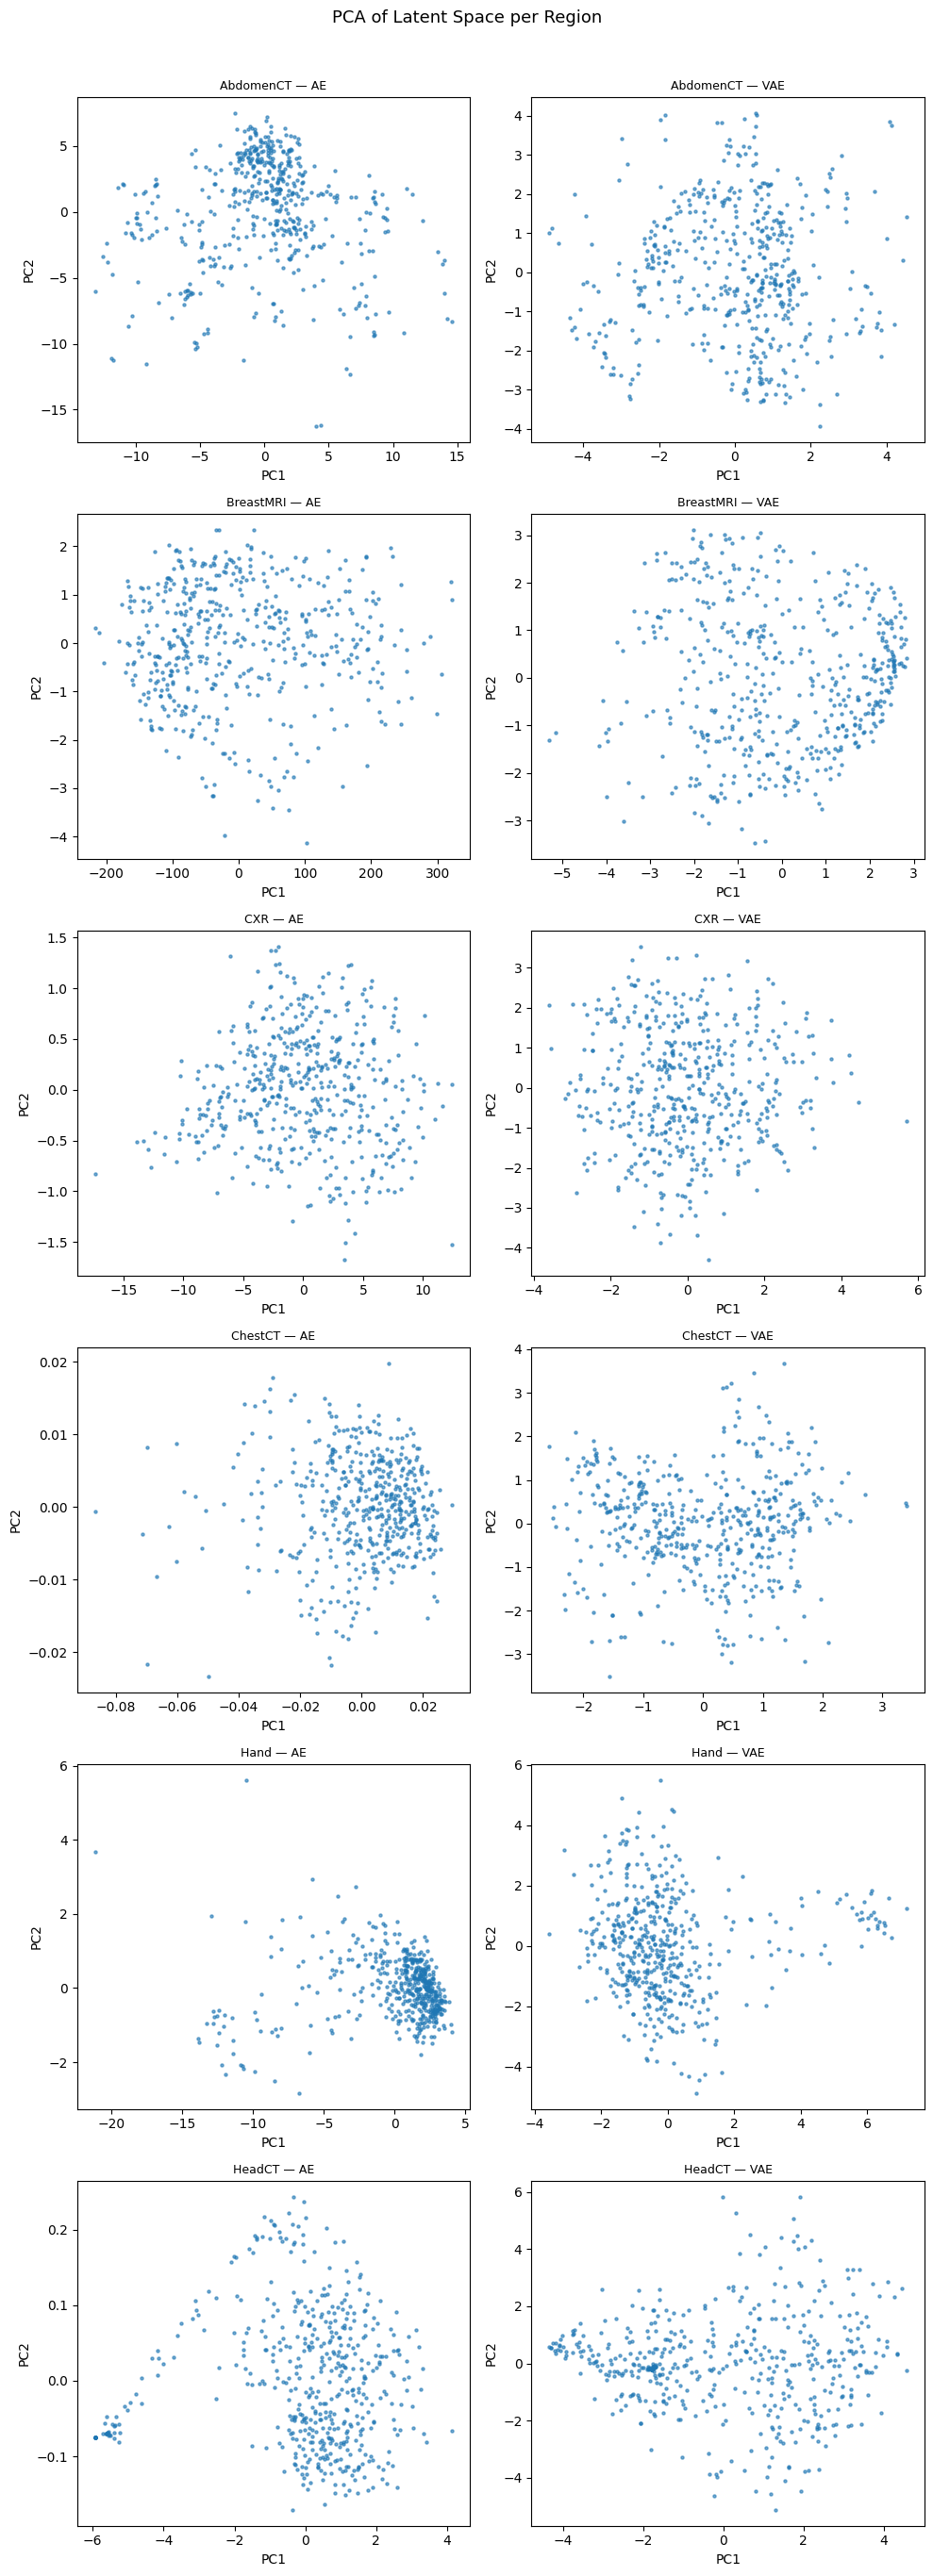

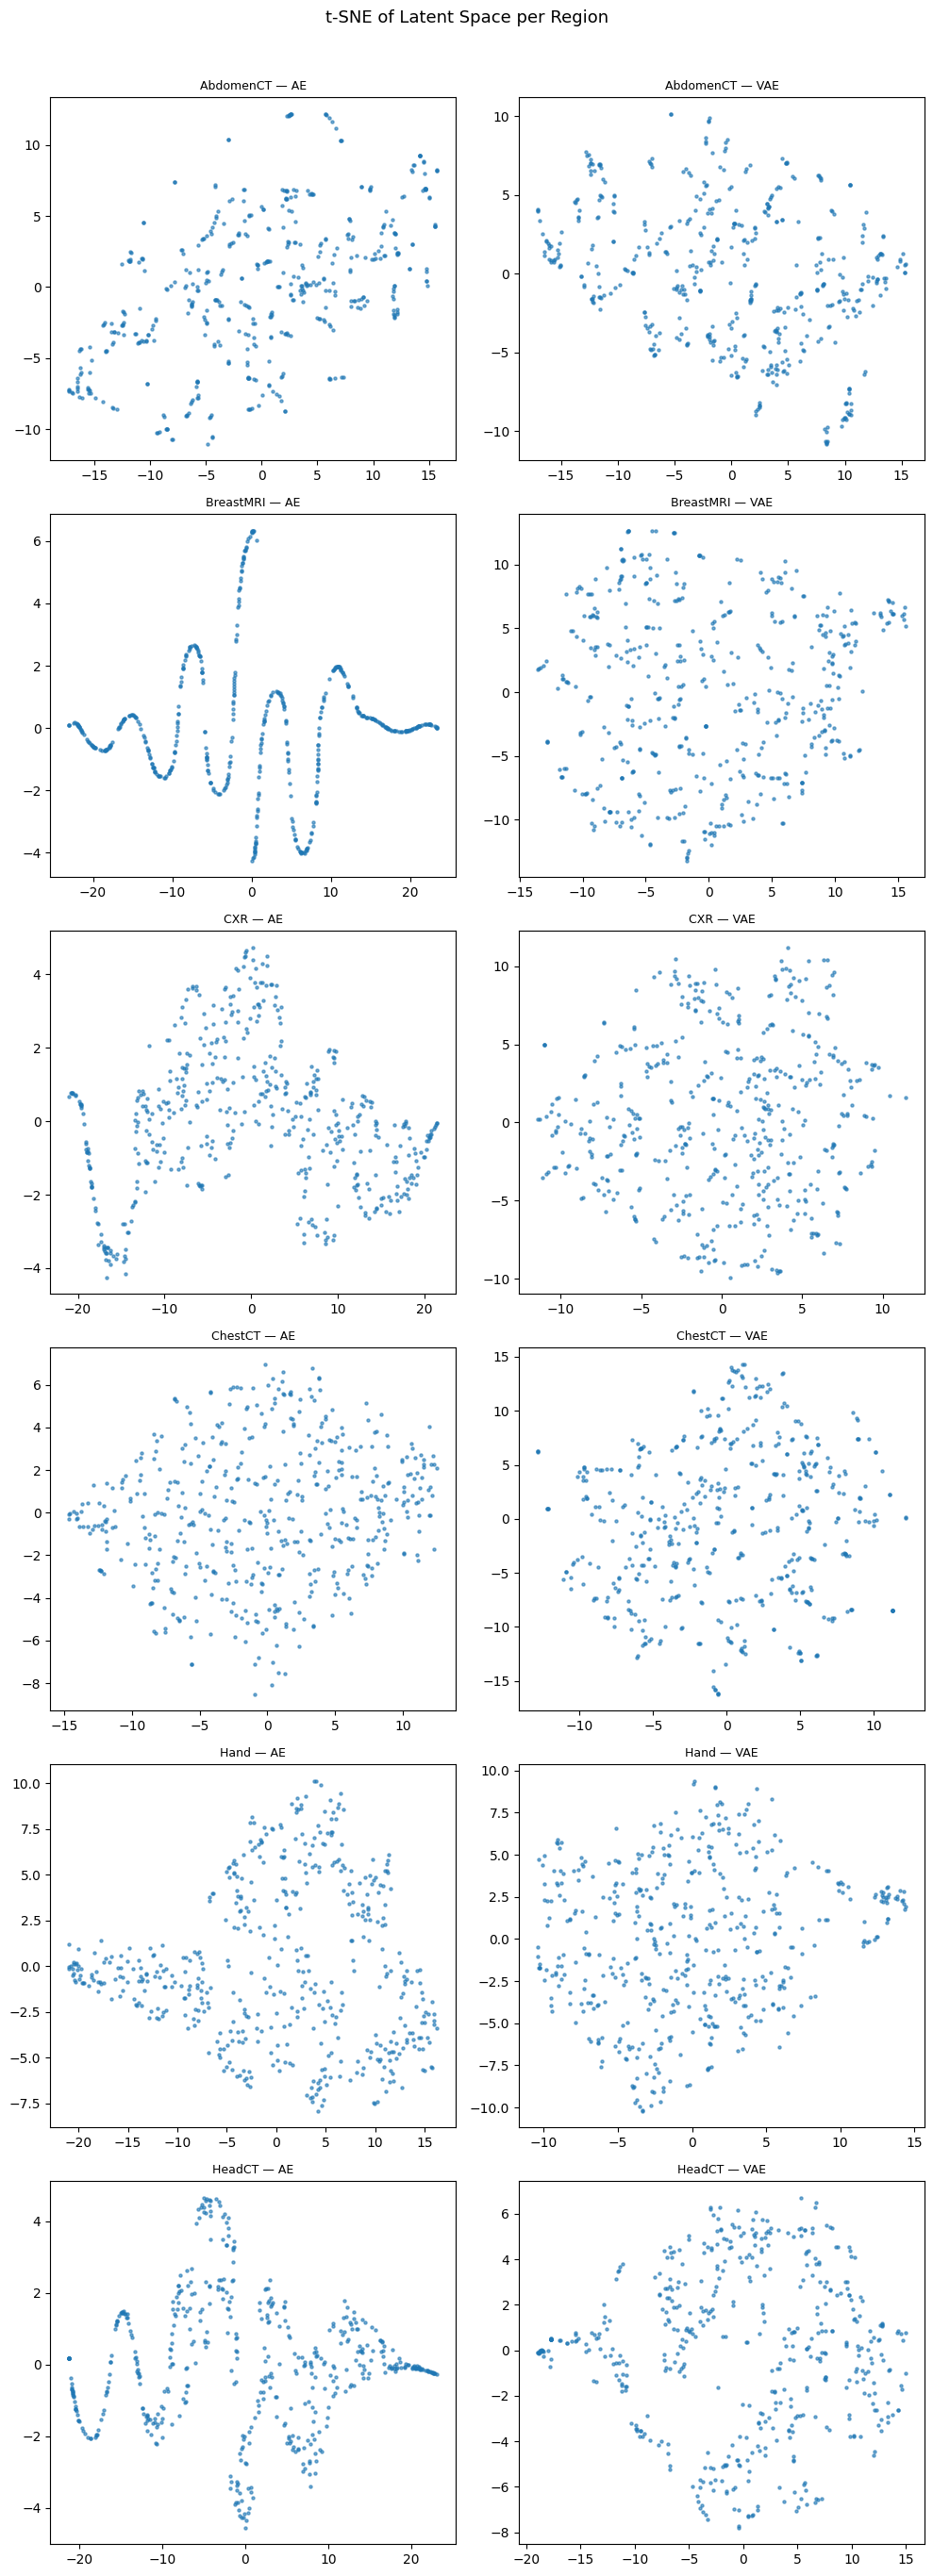

In [9]:
fig_pca,  axes_pca  = plt.subplots(n, 2, figsize=(10, 4.5*n))
fig_tsne, axes_tsne = plt.subplots(n, 2, figsize=(10, 4.5*n))
if n == 1:
    axes_pca  = axes_pca[np.newaxis, :]
    axes_tsne = axes_tsne[np.newaxis, :]

for i, region in enumerate(REGIONS):
    r = results[region]
    vis_paths = r['val_paths'][:500]   # 500 samples per region is enough
    vis_ds = make_vis_ds(vis_paths)

    imgs_all = np.concatenate([b[0].numpy() for b in vis_ds])

    ae_z       = r['ae_enc'].predict(imgs_all, verbose=0)
    vae_z, _   = r['vae_enc'].predict(imgs_all, verbose=0)

    for j, (z, label) in enumerate([(ae_z, 'AE'), (vae_z, 'VAE')]):
        # PCA
        z_pca = PCA(2).fit_transform(z)
        axes_pca[i,j].scatter(z_pca[:,0], z_pca[:,1], s=5, alpha=0.6)
        axes_pca[i,j].set_title(f'{region} — {label}', fontsize=9)
        axes_pca[i,j].set_xlabel('PC1'); axes_pca[i,j].set_ylabel('PC2')

        # t-SNE
        z_tsne = TSNE(2, random_state=42, n_iter=300).fit_transform(z)
        axes_tsne[i,j].scatter(z_tsne[:,0], z_tsne[:,1], s=5, alpha=0.6)
        axes_tsne[i,j].set_title(f'{region} — {label}', fontsize=9)

fig_pca.suptitle('PCA of Latent Space per Region', fontsize=13, y=1.01)
fig_pca.tight_layout()
fig_pca.savefig('latent_pca_all_regions.png', dpi=100, bbox_inches='tight')

fig_tsne.suptitle('t-SNE of Latent Space per Region', fontsize=13, y=1.01)
fig_tsne.tight_layout()
fig_tsne.savefig('latent_tsne_all_regions.png', dpi=100, bbox_inches='tight')

plt.show()

## 9. VAE Sample Generation — All Regions

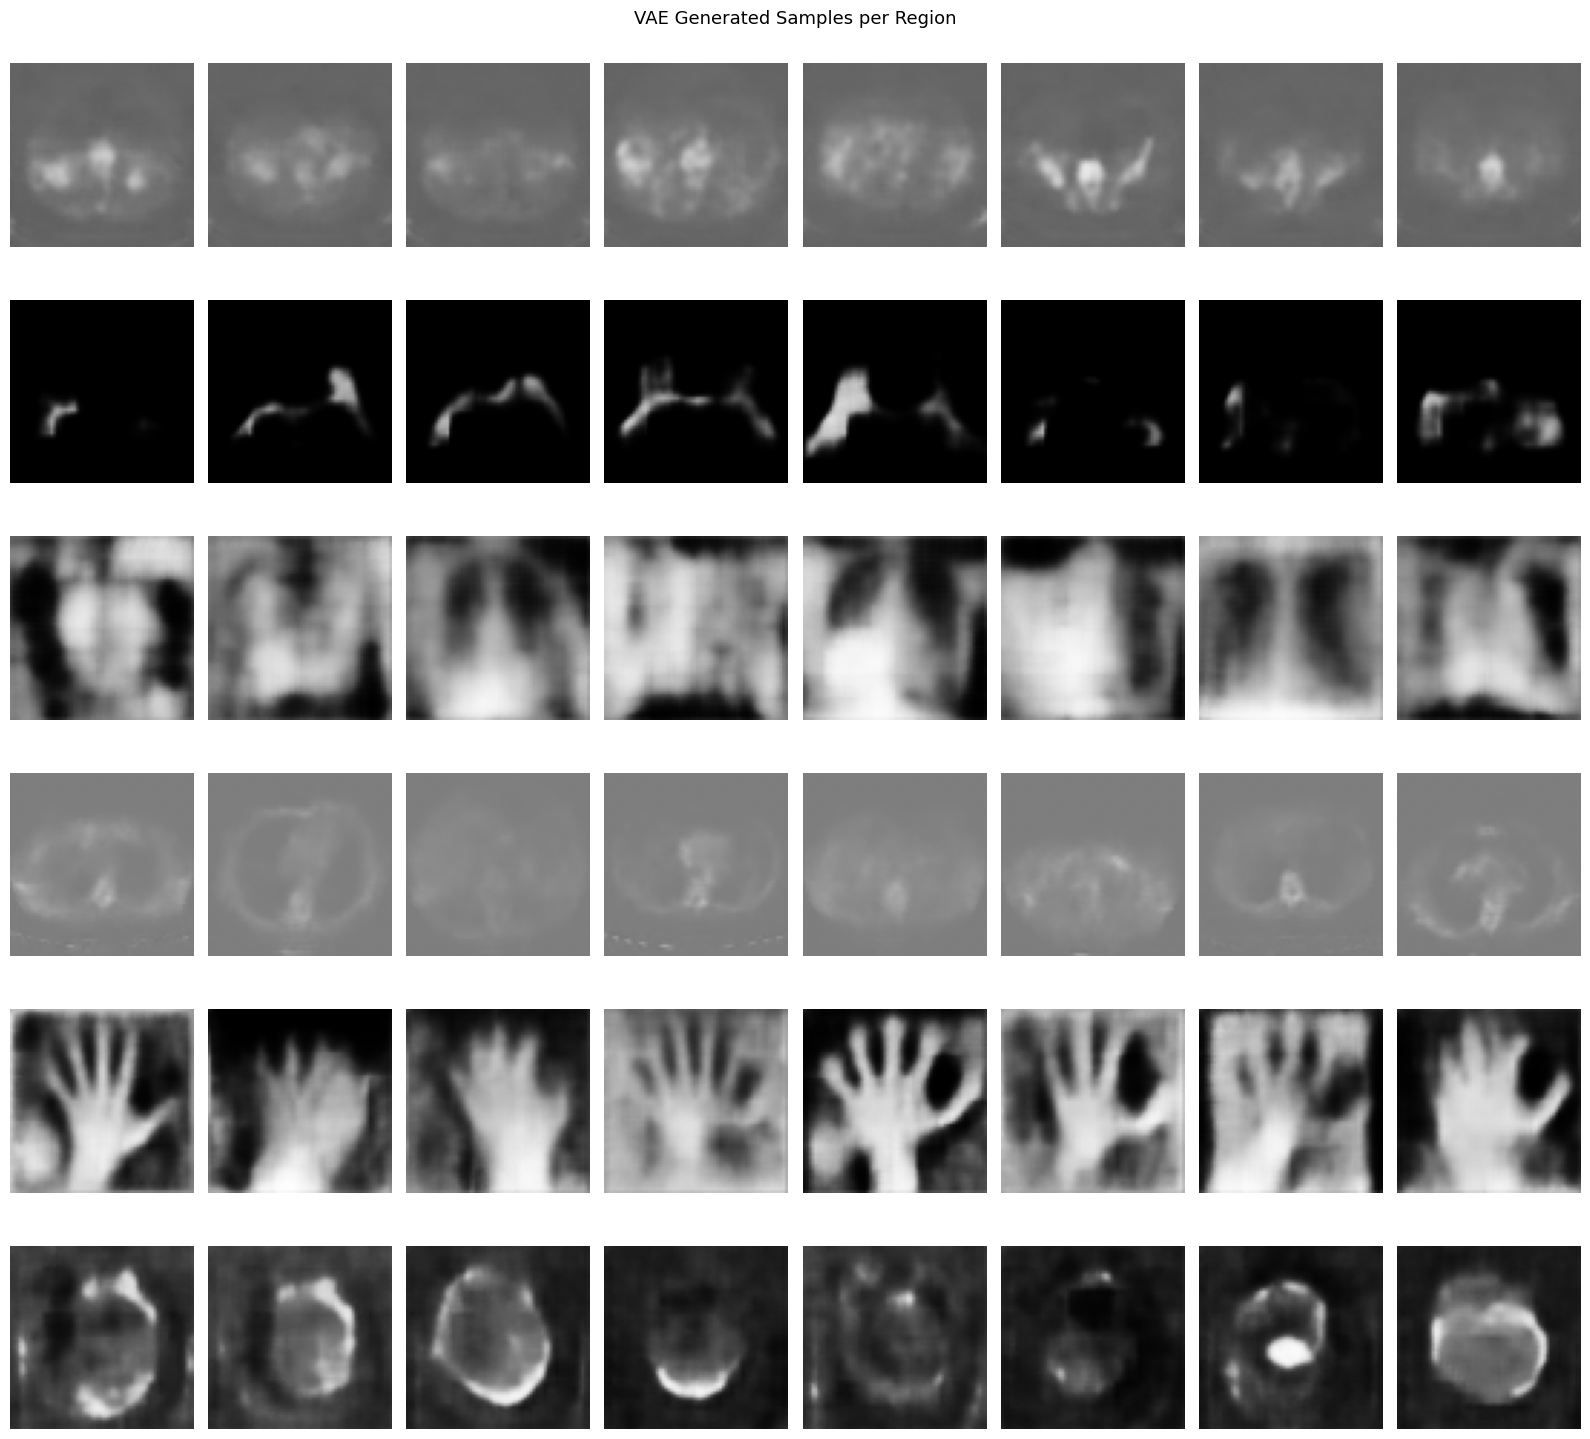

In [10]:
fig, axes = plt.subplots(n, 8, figsize=(16, 2.5*n))
if n == 1: axes = axes[np.newaxis, :]

for i, region in enumerate(REGIONS):
    samples = results[region]['vae_dec'].predict(
        np.random.randn(8, LATENT_DIM), verbose=0)
    for j in range(8):
        axes[i,j].imshow(samples[j].squeeze(), cmap='gray', vmin=0, vmax=1)
        axes[i,j].axis('off')
    axes[i,0].set_ylabel(region, fontsize=9, rotation=0, labelpad=60, va='center')

plt.suptitle('VAE Generated Samples per Region', fontsize=13)
plt.tight_layout()
plt.savefig('vae_generated_all_regions.png', dpi=100)
plt.show()

## 10. Denoising — All Regions

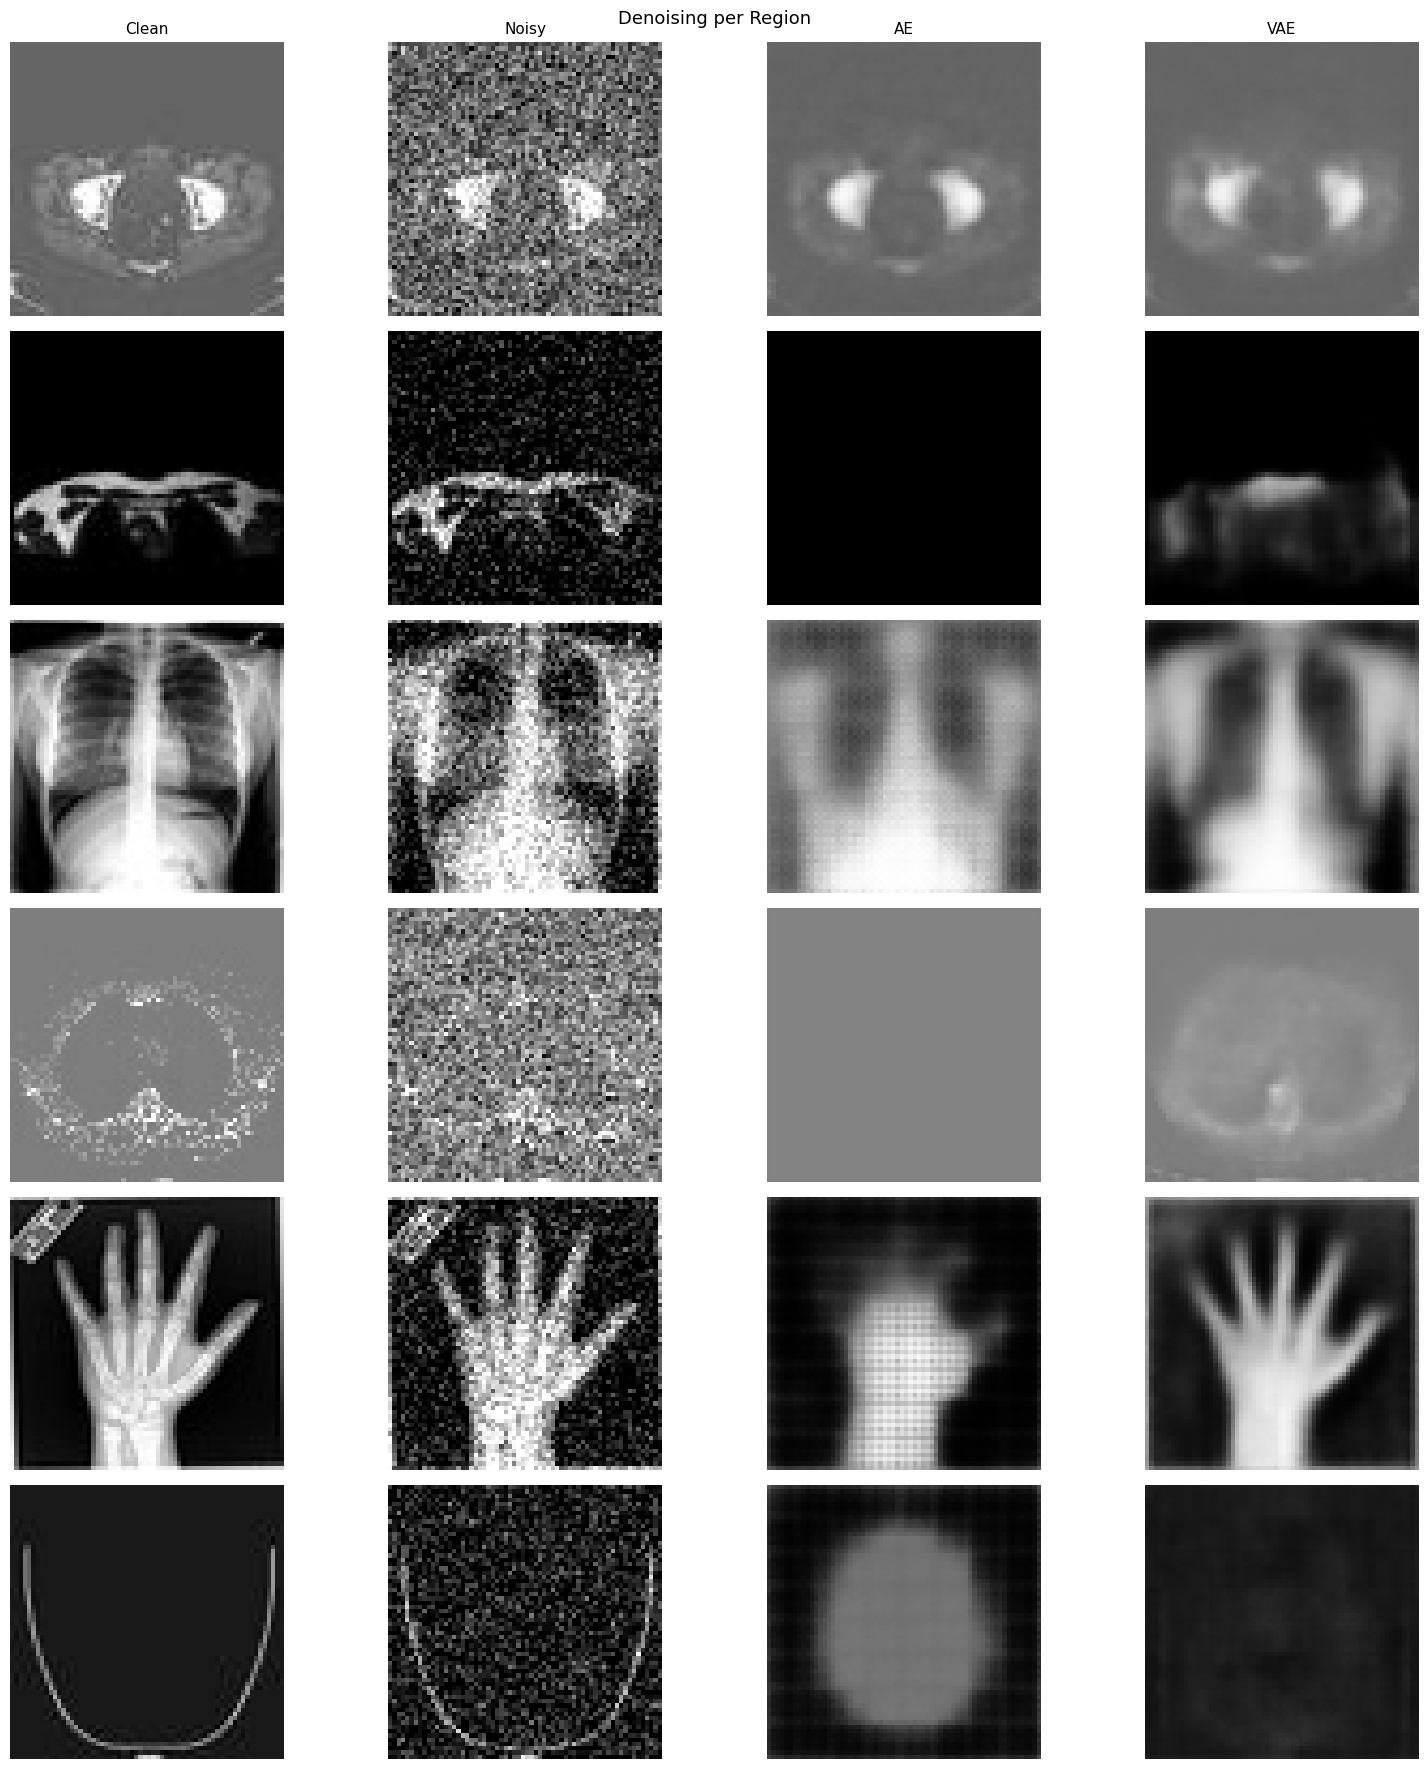

In [11]:
fig, axes = plt.subplots(n, 4, figsize=(16, 3*n))
if n == 1: axes = axes[np.newaxis, :]

for i, region in enumerate(REGIONS):
    r     = results[region]
    va_ds = make_region_ds(r['val_paths'], training=False)
    clean = next(iter(va_ds))[0][:1].numpy()  # 1 sample per region for compact view
    noisy = np.clip(clean + np.random.normal(0, 0.15, clean.shape).astype(np.float32), 0, 1)

    ae_dn  = r['ae'].predict(noisy,  verbose=0)
    vae_dn = r['vae'].predict(noisy, verbose=0)

    for j, (img, t) in enumerate(zip(
            [clean[0], noisy[0], ae_dn[0], vae_dn[0]],
            ['Clean', 'Noisy', 'AE', 'VAE'])):
        axes[i,j].imshow(img.squeeze(), cmap='gray', vmin=0, vmax=1)
        axes[i,j].axis('off')
        if i == 0: axes[i,j].set_title(t, fontsize=11)
    axes[i,0].set_ylabel(region, fontsize=9, rotation=0, labelpad=60, va='center')

plt.suptitle('Denoising per Region', fontsize=13)
plt.tight_layout()
plt.savefig('denoising_all_regions.png', dpi=100)
plt.show()

## 11. Summary Table — AE vs VAE per Region

In [12]:
rows = []
for region in REGIONS:
    r  = results[region]
    ah = r['ae_hist'].history
    vh = r['vae_hist'].history

    # Reconstruction MSE on val
    va_ds = make_region_ds(r['val_paths'], training=False)
    orig  = next(iter(va_ds))[0][:16].numpy()
    ae_r  = r['ae'].predict(orig,  verbose=0)
    vae_r = r['vae'].predict(orig, verbose=0)

    rows.append({
        'Region':            region,
        'AE Val Loss':       round(ah['val_loss'][-1], 4),
        'VAE Val Total':     round(vh['val_total_loss'][-1], 2),
        'VAE Val KL':        round(vh['val_kl_loss'][-1], 4),
        'AE MSE (sample)':   round(float(np.mean((orig - ae_r)**2)), 4),
        'VAE MSE (sample)':  round(float(np.mean((orig - vae_r)**2)), 4),
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))
df.to_csv('summary_per_region.csv', index=False)
print('\nSaved to summary_per_region.csv')

   Region  AE Val Loss  VAE Val Total  VAE Val KL  AE MSE (sample)  VAE MSE (sample)
AbdomenCT       0.0029          17.55      1.4419           0.0030            0.0039
BreastMRI       0.0591          39.39      3.1941           0.0603            0.0091
      CXR       0.0187          43.79      3.1485           0.0498            0.0111
  ChestCT       0.0032          11.25      0.6718           0.0037            0.0027
     Hand       0.0227          47.12      3.1186           0.0461            0.0107
   HeadCT       0.0280          56.16      3.0784           0.0469            0.0126

Saved to summary_per_region.csv
